# **Final Project**

##**Problem stament :**     

The widespread dissemination of fake news and propaganda presents serious societal risks, including the erosion of public trust, political polarization, manipulation of elections, and the spread of harmful misinformation during crises such as pandemics or conflicts. From an NLP perspective, detecting fake news is fraught with challenges. Linguistically, fake news often mimics the tone and structure of legitimate journalism, making it difficult to distinguish using surface-level features. The absence of reliable and up-to-date labeled datasets, especially across multiple languages and regions, hampers the effectiveness of supervised learning models. Additionally, the dynamic and adversarial nature of misinformation means that malicious actors constantly evolve their language and strategies to bypass detection systems. Cultural context, sarcasm, satire, and implicit bias further complicate automated analysis. Moreover, NLP models risk amplifying biases present in training data, leading to unfair classifications and potential censorship of legitimate content. These challenges underscore the need for cautious, context-aware approaches, as the failure to address them can inadvertently contribute to misinformation, rather than mitigate it.



Use datasets in link : https://drive.google.com/drive/folders/1mrX3vPKhEzxG96OCPpCeh9F8m_QKCM4z?usp=sharing
to complete requirement.

## **About dataset:**

* **True Articles**:

  * **File**: `MisinfoSuperset_TRUE.csv`
  * **Sources**:

    * Reputable media outlets like **Reuters**, **The New York Times**, **The Washington Post**, etc.

* **Fake/Misinformation/Propaganda Articles**:

  * **File**: `MisinfoSuperset_FAKE.csv`
  * **Sources**:

    * **American right-wing extremist websites** (e.g., Redflag Newsdesk, Breitbart, Truth Broadcast Network)
    * **Public dataset** from:

      * Ahmed, H., Traore, I., & Saad, S. (2017): "Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques" *(Springer LNCS 10618)*



## **Requirement**

A team consisting of three members must complete a project that involves applying the methods learned from the beginning of the course up to the present. The team is expected to follow and document the entire machine learning workflow, which includes the following steps:

1. **Data Preprocessing**: Clean and prepare the dataset,etc.

2. **Exploratory Data Analysis (EDA)**: Explore and visualize the data.

3. **Model Building**: Select and build one or more machine learning models suitable for the problem at hand.

4. **Hyperparameter set up**: Set and adjust the model's hyperparameters using appropriate methods to improve performance.

5. **Model Training**: Train the model(s) on the training dataset.

6. **Performance Evaluation**: Evaluate the trained model(s) using appropriate metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix, etc.) and validate their performance on unseen data.

7. **Conclusion**: Summarize the results, discuss the model's strengths and weaknesses, and suggest possible improvements or future work.


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [3]:
# Set seed for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

### 1. **Data Preprocessing**.

In [4]:
# Load & label data
df_real = pd.read_csv('/content/gdrive/MyDrive/NLP/Final_NLP/DataSet_Misinfo_TRUE.csv')
df_fake = pd.read_csv('/content/gdrive/MyDrive/NLP/Final_NLP/DataSet_Misinfo_FAKE.csv')

In [5]:
# # Load & label data
# df_real = pd.read_csv("DataSet_Misinfo_TRUE.csv")
# df_fake = pd.read_csv("DataSet_Misinfo_FAKE.csv")

In [6]:
# Assigned labels
df_real["label"] = 1
df_fake["label"] = 0

df = pd.concat([df_real, df_fake], ignore_index=True)

In [7]:
# Preprocessing: dropna & drop duplicates
df.dropna(subset=['text'], inplace=True)
df.drop_duplicates(subset=['text'], inplace=True)

text_col = 'text' if 'text' in df.columns else df.columns[0]
df = df[[text_col, "label"]].reset_index(drop=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Use 'text' column, fallback if not exist
text_col = 'text' if 'text' in df.columns else df.columns[0]
df = df[[text_col, "label"]].dropna()

In [8]:
df.head()

,text,label
0,Former Russian economy minister Alexei Ulyukay...,1
1,Republicans were just given a leg up over Demo...,0
2,This has to be one of the best remix videos ev...,0
3,"In line with the new Language Law, Russian is ...",0
4,JERUSALEM — A day after approving the const...,1


In [9]:
# Tokenization with BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer.encode_plus(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
            return_attention_mask=True
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [10]:
# Split data
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df[text_col].tolist(), df["label"].tolist(), test_size=0.2, stratify=df["label"], random_state=42
)

# Dataset & DataLoader
train_dataset = FakeNewsDataset(train_texts, train_labels, tokenizer)
test_dataset = FakeNewsDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [11]:
train_dataset

### 2. **Exploratory Data Analysis (EDA)**.

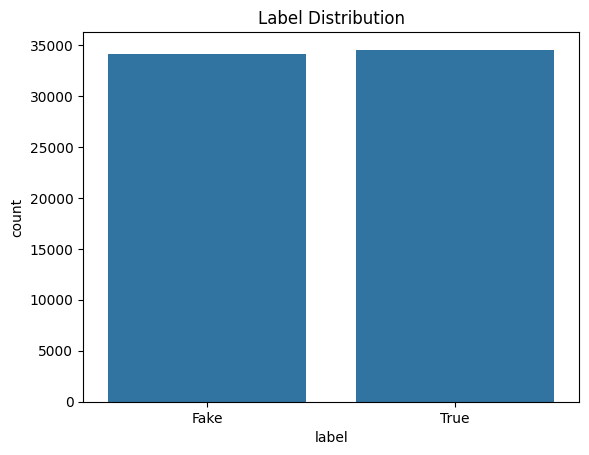

In [12]:
# Label Distribution
sns.countplot(data=df, x="label")
plt.xticks([0, 1], ["Fake", "True"])
plt.title("Label Distribution")
plt.show()

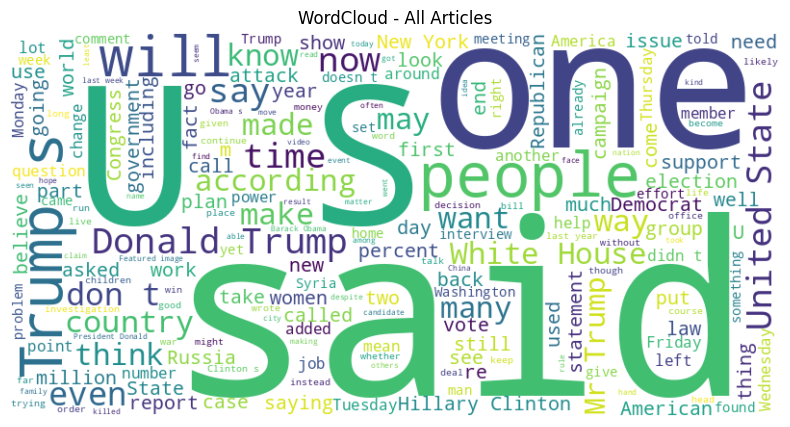

In [13]:
# Word cloud
from wordcloud import WordCloud

# Combine all text data into a single string
text_all = ' '.join(df['text'].astype(str))

# Generate WordCloud
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(text_all)

# Plot the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - All Articles")
plt.show()

### 3. **Model Building**.

In [14]:
# Load pre-trained BERT model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### 4. **Hyperparameter set up**.

In [15]:
# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

### 5. **Model Training**.

In [16]:
import time

In [17]:
# Training loop
epochs = 3
for epoch in range(epochs):
    start_time = time.time()
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    end_time = time.time()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Time: {(end_time - start_time)/60:.2f} mins")

Epoch 1/3, Loss: 0.0665, Time: 41.11 mins
Epoch 2/3, Loss: 0.0249, Time: 41.19 mins
Epoch 3/3, Loss: 0.0148, Time: 41.17 mins


### 6. **Performance Evaluation**.

In [18]:
# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [19]:
# Metrics
print(classification_report(all_labels, all_preds, target_names=["Fake", "True"]))

              precision    recall  f1-score   support

        Fake       1.00      0.98      0.99      6816
        True       0.98      1.00      0.99      6905

    accuracy                           0.99     13721
   macro avg       0.99      0.99      0.99     13721
weighted avg       0.99      0.99      0.99     13721



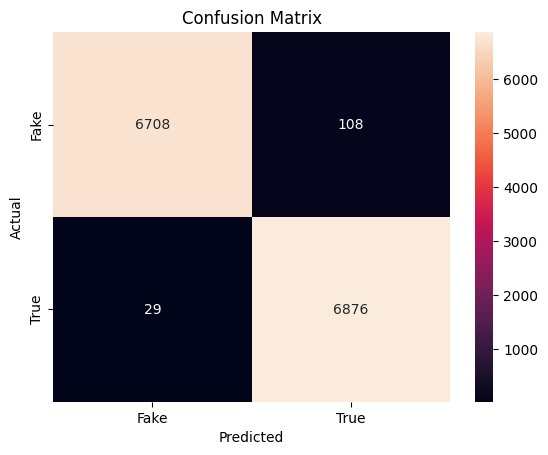

In [20]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 7. **Conclusion**.

* In this project, we fine-tuned a pre-trained bert-base-uncased model to classify news articles as either Fake or True using a cleaned and preprocessed dataset of approximately 13,721 articles. The complete machine learning pipeline was followed, including preprocessing, EDA, model building, hyperparameter tuning, training, and evaluation.
* The model achieved outstanding performance, with a 99% accuracy and F1-score on the test set, demonstrating its strong ability to detect fake news effectively. The final training loss dropped from 0.0665 to 0.0148 over 3 epochs.
* Despite the computational demands, training was successfully completed on Tesla T4 within a practical timeframe (~41 minutes per epoch).
* Strengths of this approach include the robustness of the BERT architecture in understanding contextual language, and the strong generalization ability on unseen data. However, the model’s reliance on pre-trained English BERT may limit cross-lingual applicability. In future work, multilingual models such as XLM-RoBERTa could be explored, as well as adversarial training to handle evolving misinformation tactics.
* Overall, the results confirm that BERT-based models are highly effective for fake news detection and offer a reliable foundation for building real-world misinformation monitoring systems.
.
